In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [132]:
dataset = pd.read_csv('heart_disease_risk_dataset_earlymed.csv')

In [133]:
df = pd.DataFrame(dataset)

In [134]:
df.head()

,Chest_Pain,Shortness_of_Breath,Fatigue,Palpitations,Dizziness,Swelling,Pain_Arms_Jaw_Back,Cold_Sweats_Nausea,High_BP,High_Cholesterol,Diabetes,Smoking,Obesity,Sedentary_Lifestyle,Family_History,Chronic_Stress,Gender,Age,Heart_Risk
0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,48.0,0.0
1,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,46.0,0.0
2,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,1.0,1.0,1.0,0.0,0.0,1.0,66.0,0.0
3,1.0,1.0,0.0,1.0,0.0,0.0,1.0,1.0,1.0,0.0,1.0,1.0,0.0,1.0,1.0,1.0,1.0,60.0,1.0
4,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,69.0,0.0


In [135]:
from sklearn.model_selection import train_test_split

In [136]:
x = df.drop(['Heart_Risk'], axis='columns')

In [31]:
from sklearn.preprocessing import MinMaxScaler

In [61]:
scaler = MinMaxScaler()

In [68]:
x[['Age']] = scaler.fit_transform(x[['Age']])

In [137]:
x.head()

,Chest_Pain,Shortness_of_Breath,Fatigue,Palpitations,Dizziness,Swelling,Pain_Arms_Jaw_Back,Cold_Sweats_Nausea,High_BP,High_Cholesterol,Diabetes,Smoking,Obesity,Sedentary_Lifestyle,Family_History,Chronic_Stress,Gender,Age
0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,48.0
1,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,46.0
2,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,1.0,1.0,1.0,0.0,0.0,1.0,66.0
3,1.0,1.0,0.0,1.0,0.0,0.0,1.0,1.0,1.0,0.0,1.0,1.0,0.0,1.0,1.0,1.0,1.0,60.0
4,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,69.0


In [138]:
y = df.Heart_Risk

In [139]:
y.head()

0    0.0
1    0.0
2    0.0
3    1.0
4    0.0
Name: Heart_Risk, dtype: float64

In [140]:
X_test, X_train, y_test, y_train = train_test_split(x, y, test_size=0.3, random_state=4)

In [141]:
from sklearn.ensemble import RandomForestClassifier

In [142]:
rf = RandomForestClassifier(random_state=4)

In [143]:
rf.fit(X_train, y_train)

RandomForestClassifier(random_state=4)

In [144]:
for feature, importance in zip(x.columns, rf.feature_importances_):
    print(feature, importance)

Chest_Pain 0.07929455317255281
Shortness_of_Breath 0.10837380927737478
Fatigue 0.08911594215764197
Palpitations 0.10575154427321941
Dizziness 0.09702272544418854
Swelling 0.07577443288398467
Pain_Arms_Jaw_Back 0.09562469037129848
Cold_Sweats_Nausea 0.11230162767782911
High_BP 0.010930811446167272
High_Cholesterol 0.009989618943309197
Diabetes 0.008777064688527224
Smoking 0.008804971097344296
Obesity 0.009599471215612077
Sedentary_Lifestyle 0.011635356392697183
Family_History 0.01010561105475991
Chronic_Stress 0.00949513053234758
Gender 0.005093791338061921
Age 0.1523088480330836


In [79]:
# rom sklearn.neighbors import KNeighborsClassifier

In [80]:
# knn = KNeighborsClassifier(n_neighbors=10)

In [81]:
# knn.fit(X_train, y_train)

In [145]:
rf.score(X_train, y_train)

1.0

In [146]:
rf.score(X_test, y_test)

0.9915102040816327

In [147]:
from sklearn.model_selection import cross_val_score

scores = cross_val_score(rf, x, y, cv=5)

print(scores)
print("Average:", scores.mean())

[0.9905     0.9925     0.99285714 0.992      0.99192857]
Average: 0.9919571428571429


In [148]:
from sklearn.metrics import r2_score

In [149]:
rf_pred = rf.predict(X_test)

In [150]:
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay

In [151]:
print(classification_report(y_test, rf_pred))

              precision    recall  f1-score   support

         0.0       0.99      0.99      0.99     24519
         1.0       0.99      0.99      0.99     24481

    accuracy                           0.99     49000
   macro avg       0.99      0.99      0.99     49000
weighted avg       0.99      0.99      0.99     49000



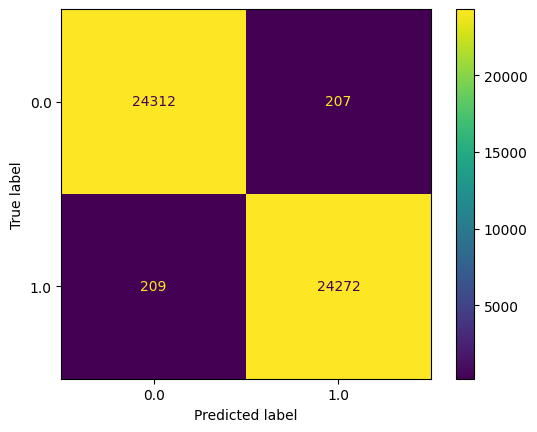

In [152]:
ConfusionMatrixDisplay.from_predictions(y_test, rf_pred)

In [153]:
score = r2_score(rf_pred, y_test)

In [154]:
score

0.9660407913769079

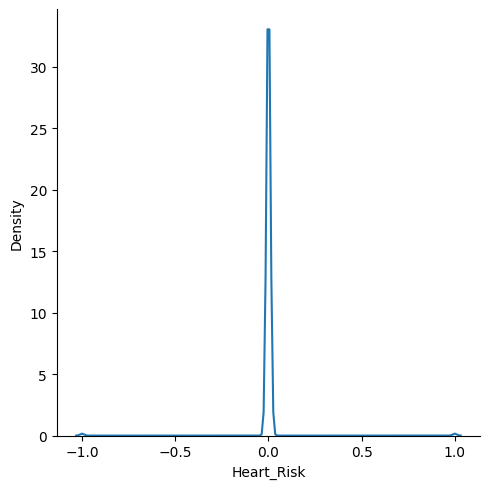

In [155]:
sns.displot(rf_pred-y_test, kind='kde')

In [156]:
y_test[:10]

42916    0.0
44559    0.0
27353    1.0
25359    1.0
32655    0.0
13796    1.0
8298     1.0
62138    1.0
13573    0.0
59346    0.0
Name: Heart_Risk, dtype: float64

In [157]:
input_data = (1,0,0,1,0,0,0,0,1,1,0,1,1,1,0,0,1,44)

In [158]:
input_data_as_n = np.asarray(input_data)

In [159]:
input_data_reshaped = input_data_as_n.reshape(1,-1)

In [160]:
prediction = rf.predict(input_data_reshaped)

C:\Users\ganga\AppData\Roaming\Python\Python312\site-packages\sklearn\base.py:493: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(


In [161]:
print(prediction)

[0.]


In [162]:
if(prediction[0] == 0):
    print("Person has no heart disease risk")
else:
    print("Person has heart disease")

Person has no heart disease risk


In [163]:
import pickle 

In [164]:
filename = 'heart_risk_modal.sav'

In [165]:
pickle.dump(rf, open(filename, 'wb'))

In [166]:
loaded_model = pickle.load(open('heart_risk_modal.sav', 'rb'))

In [167]:
for column in x.columns:
  print(column)

Chest_Pain
Shortness_of_Breath
Fatigue
Palpitations
Dizziness
Swelling
Pain_Arms_Jaw_Back
Cold_Sweats_Nausea
High_BP
High_Cholesterol
Diabetes
Smoking
Obesity
Sedentary_Lifestyle
Family_History
Chronic_Stress
Gender
Age


In [168]:
print(df['Heart_Risk'].value_counts())

Heart_Risk
0.0    35000
1.0    35000
Name: count, dtype: int64


In [169]:
print(x.columns.tolist())

['Chest_Pain', 'Shortness_of_Breath', 'Fatigue', 'Palpitations', 'Dizziness', 'Swelling', 'Pain_Arms_Jaw_Back', 'Cold_Sweats_Nausea', 'High_BP', 'High_Cholesterol', 'Diabetes', 'Smoking', 'Obesity', 'Sedentary_Lifestyle', 'Family_History', 'Chronic_Stress', 'Gender', 'Age']


In [192]:
row = X_test.iloc[35013]

print("Actual:", y_test.iloc[35013])
print("Predicted:", rf.predict([row])[0])

Actual: 1.0
Predicted: 1.0


C:\Users\ganga\AppData\Roaming\Python\Python312\site-packages\sklearn\base.py:493: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(
